SCRIPT 1 — TRAIN_GAN

In [ ]:
# =======================
#  GOOGLE DRIVE
# =======================
from google.colab import drive
drive.mount('/content/drive')

import os

SAVE_DIR = "/content/drive/MyDrive/GAN_NUMEROS_MODELOS"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Modelos serão salvos em:", SAVE_DIR)


Mounted at /content/drive
Modelos serão salvos em: /content/drive/MyDrive/GAN_NUMEROS_MODELOS


Imports e Configurações

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

latent_dim = 128
num_classes = 10

epochs_teacher = 60
epochs_student = 50
batch_size = 64


Device: cpu


GAN Convolucional — Gerador + Discriminador
Generator cDCGAN

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.label_emb = nn.Embedding(num_classes, 10)

        self.init_size = 7


        self.l1 = nn.Linear(latent_dim + 10, 128 * 7 * 7)

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(128),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Conv2d(32, 1, 3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        c = self.label_emb(labels)
        x = torch.cat((noise, c), dim=1)
        out = self.l1(x)
        out = out.view(out.size(0), 128, 7, 7)
        img = self.conv_blocks(out)
        return img


Discriminator cDCGAN

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.label_emb = nn.Embedding(num_classes, 1 * 28 * 28)

        self.model = nn.Sequential(
            nn.Conv2d(2, 32, 3, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 64, 3, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 1),
            nn.Sigmoid(),
        )

    def forward(self, img, labels):
        label_img = self.label_emb(labels).view(img.size(0), 1, 28, 28)
        x = torch.cat((img, label_img), dim=1)
        return self.model(x)


Instanciar GAN A e GAN B

In [ ]:
G_A = Generator().to(device)
D_A = Discriminator().to(device)

G_B = Generator().to(device)
D_B = Discriminator().to(device)

criterion = nn.BCELoss()

opt_GA = optim.Adam(G_A.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_DA = optim.Adam(D_A.parameters(), lr=0.0002, betas=(0.5, 0.999))

opt_GB = optim.Adam(G_B.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_DB = optim.Adam(D_B.parameters(), lr=0.0002, betas=(0.5, 0.999))


Dataset MNIST para GAN A

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_data = datasets.MNIST(root="./", train=True, download=True, transform=transform)
loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, drop_last=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 38.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.09MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.29MB/s]


Função Auxiliar

In [ ]:
def sample_noise_labels(bs):
    noise = torch.randn(bs, latent_dim).to(device)
    labels = torch.randint(0, num_classes, (bs,)).to(device)
    return noise, labels

def show_samples(G, epoch):
    G.eval()
    noise = torch.randn(10, latent_dim).to(device)
    labels = torch.arange(0, 10).to(device)

    with torch.no_grad():
        imgs = G(noise, labels).cpu()

    plt.figure(figsize=(10,2))
    for i in range(10):
        plt.subplot(1,10,i+1)
        plt.imshow(imgs[i][0], cmap='gray')
        plt.axis('off')
    plt.suptitle(f"Epoch {epoch}")
    plt.show()

Treino GAN A (professor)

=== Treinando GAN A (professor) ===
[Teacher] Epoch 1/60 | D: 1.2477 G: 0.8226
[Teacher] Epoch 2/60 | D: 1.2985 G: 0.7566
[Teacher] Epoch 3/60 | D: 1.2782 G: 0.8233
[Teacher] Epoch 4/60 | D: 1.4859 G: 0.6482
[Teacher] Epoch 5/60 | D: 1.2445 G: 0.7767
[Teacher] Epoch 6/60 | D: 1.1382 G: 0.9218
[Teacher] Epoch 7/60 | D: 1.8114 G: 0.6412
[Teacher] Epoch 8/60 | D: 1.3347 G: 0.6135
[Teacher] Epoch 9/60 | D: 1.0811 G: 0.9561
[Teacher] Epoch 10/60 | D: 1.5276 G: 0.6316


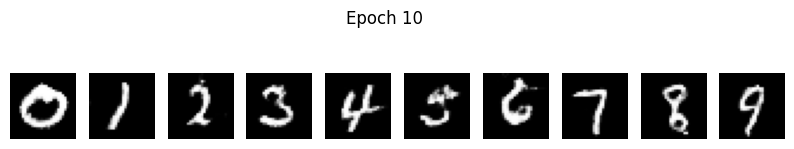

[Teacher] Epoch 11/60 | D: 1.0803 G: 0.7731
[Teacher] Epoch 12/60 | D: 1.2881 G: 0.6514
[Teacher] Epoch 13/60 | D: 1.3301 G: 0.7619
[Teacher] Epoch 14/60 | D: 1.5357 G: 0.5830
[Teacher] Epoch 15/60 | D: 1.0244 G: 0.9881
[Teacher] Epoch 16/60 | D: 1.2145 G: 0.8608
[Teacher] Epoch 17/60 | D: 1.3645 G: 0.6145
[Teacher] Epoch 18/60 | D: 0.9575 G: 1.0388
[Teacher] Epoch 19/60 | D: 1.1271 G: 0.8279
[Teacher] Epoch 20/60 | D: 1.3879 G: 0.6245


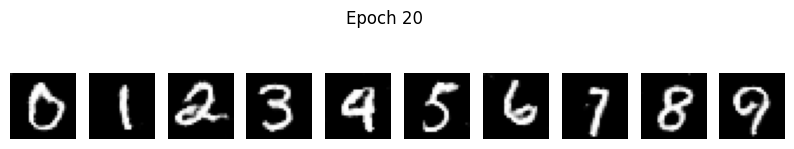

[Teacher] Epoch 21/60 | D: 1.1989 G: 0.7642
[Teacher] Epoch 22/60 | D: 1.7875 G: 0.6025
[Teacher] Epoch 23/60 | D: 1.0547 G: 1.0297
[Teacher] Epoch 24/60 | D: 1.3403 G: 0.6682
[Teacher] Epoch 25/60 | D: 1.1054 G: 0.6695


In [ ]:
print("=== Treinando GAN A (professor) ===")

for epoch in range(epochs_teacher):
    for imgs, labels in loader:
        bs = imgs.size(0)
        imgs, labels = imgs.to(device), labels.to(device)

        # --- Train D_A ---
        opt_DA.zero_grad()
        real_loss = criterion(D_A(imgs, labels), torch.ones(bs, 1).to(device))

        noise, lbl_fake = sample_noise_labels(bs)
        fake_imgs = G_A(noise, lbl_fake)
        fake_loss = criterion(D_A(fake_imgs.detach(), lbl_fake), torch.zeros(bs, 1).to(device))

        d_loss = real_loss + fake_loss
        d_loss.backward()
        opt_DA.step()

        # --- Train G_A ---
        opt_GA.zero_grad()
        g_loss = criterion(D_A(fake_imgs, lbl_fake), torch.ones(bs, 1).to(device))
        g_loss.backward()
        opt_GA.step()

    print(f"[Teacher] Epoch {epoch+1}/{epochs_teacher} | D: {d_loss.item():.4f} G: {g_loss.item():.4f}")

    if (epoch + 1) % 10 == 0:
        show_samples(G_A, epoch + 1)

G_A.eval()
print("GAN A concluída.")


Treino GAN B (aluno)

In [ ]:
print("\n=== Treinando GAN B (aprendiz) ===")

from tqdm import tqdm

for epoch in range(epochs_student):
    pbar = tqdm(loader, desc=f"[Student] Epoch {epoch+1}/{epochs_student}", leave=False)

    for imgs, labels in pbar:
        bs = batch_size

        noise_t, labels_t = sample_noise_labels(bs)
        with torch.no_grad():
            teacher_imgs = G_A(noise_t, labels_t)

        noise_s = torch.randn(bs, latent_dim).to(device)
        student_imgs = G_B(noise_s, labels_t)

        opt_DB.zero_grad()
        real_loss = criterion(D_B(teacher_imgs, labels_t), torch.ones(bs, 1).to(device))
        fake_loss = criterion(D_B(student_imgs.detach(), labels_t), torch.zeros(bs, 1).to(device))
        d_loss = real_loss + fake_loss
        d_loss.backward()
        opt_DB.step()

        opt_GB.zero_grad()
        g_loss = criterion(D_B(student_imgs, labels_t), torch.ones(bs, 1).to(device))
        g_loss.backward()
        opt_GB.step()

        pbar.set_postfix({"D_loss": f"{d_loss.item():.4f}", "G_loss": f"{g_loss.item():.4f}"})

    print(f"[Student] Epoch {epoch+1}/{epochs_student} | D: {d_loss.item():.4f} G: {g_loss.item():.4f}")


Salvar Modelos no Drive

In [ ]:
torch.save(G_A.state_dict(), f"{SAVE_DIR}/G_A.pth")
torch.save(D_A.state_dict(), f"{SAVE_DIR}/D_A.pth")
torch.save(G_B.state_dict(), f"{SAVE_DIR}/G_B.pth")
torch.save(D_B.state_dict(), f"{SAVE_DIR}/D_B.pth")

print(f"\nModelos salvos em:\n{SAVE_DIR}")


COMEÇO DO SCRIPT 2 — GENERATE_NUMBER


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

latent_dim = 100
num_classes = 10
device = "cuda" if torch.cuda.is_available() else "cpu"

LOAD_DIR = "/content/drive/MyDrive/GAN_NUMEROS_MODELOS"
print("Carregando modelos de:", LOAD_DIR)


Carregar o modelo cDCGAN

Copie aqui as MESMAS CLASSES Generator e Discriminator do Script 1.

In [ ]:
latent_dim = 100
G_B = Generator().to(device)
G_B.load_state_dict(torch.load(f"{LOAD_DIR}/G_B.pth"))

G_B.eval()
print("Modelo carregado!")

Função para desenhar número

In [ ]:
def gerar_numero():
    n = input("Digite um número entre 0 e 9: ")

    if not n.isdigit() or not (0 <= int(n) <= 9):
        print("Entrada inválida.")
        return

    label = torch.tensor([int(n)]).to(device)
    noise = torch.randn(1, latent_dim).to(device)

    with torch.no_grad():
        img = G_B(noise, label).cpu().numpy().squeeze()

    plt.imshow(img, cmap="gray")
    plt.title(f"GAN B gerou: {n}")
    plt.axis("off")
    plt.show()

gerar_numero()

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def gerar_todos_numeros():
    imgs = []
    labels = list(range(10))

    for n in labels:
        label = torch.tensor([n]).to(device)
        noise = torch.randn(1, latent_dim).to(device)

        with torch.no_grad():
            img = G_B(noise, label).cpu().numpy().squeeze()
            imgs.append(img)

    plt.figure(figsize=(10, 4))

    for i, img in enumerate(imgs):
        plt.subplot(2, 5, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"{i}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

gerar_todos_numeros()